# MAE 6246 - Week 4 Python Example
## Modal Analysis, Phase Portraits, and Stability
**Lecture:** Friday, September 18, 2026

This notebook follows the revised Week 4 course note. Section numbers below refer to the note. Run the cells in order; every figure is generated here using NumPy, SciPy, and Matplotlib.

**Core lecture:** Sections 2-6. **Optional extensions:** Sections 7-8.

The organizing idea is
$$x_0=\sum_i c_i v_i\quad\Longrightarrow\quad x(t)=\sum_i c_i e^{\lambda_i t}v_i.$$
First decompose the initial state, then evolve each component and add the resulting modes.

## 1. Learning objectives and setup

1. Decompose an initial state in an eigenvector basis.
2. Reconstruct a trajectory from its modal contributions.
3. Enforce conjugate coefficients for a real initial state and interpret oscillation frequency.
4. Relate eigenstructure to phase portraits and stability.
5. Check the role of Jordan blocks on the imaginary axis.

Assume zero input and initial time $t_0=0$. An ordinary eigenvector expansion requires a complete eigenvector basis. For defective matrices, we use the matrix exponential directly.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, svdvals
from IPython.display import display, HTML

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
SLOW, FAST, TOTAL = "#167d9a", "#d18423", "#222a42"

def exact_response(A, x0, times):
    return np.array([expm(A * t) @ x0 for t in times])

def modal_response(P, eigenvalues, coefficients, times):
    # Shape: (time, state component, mode). Columns of P are eigenvectors.
    amplitudes = np.exp(times[:, None] * eigenvalues[None, :]) * coefficients
    contributions = P[None, :, :] * amplitudes[:, None, :]
    return contributions, contributions.sum(axis=2)

print("Setup complete.")

Setup complete.


## 2. Eigenpairs as dynamical modes
### 2.1 Start with the initial state
Use the note's overdamped oscillator:
$$\ddot q+4\dot q+3q=0,\qquad
A=\begin{bmatrix}0&1\\-3&-4\end{bmatrix},\qquad
x_0=\begin{bmatrix}2\\-4\end{bmatrix}.$$
Its eigenpairs are
$$\lambda_1=-1,\ v_1=\begin{bmatrix}1\\-1\end{bmatrix},\qquad
\lambda_2=-3,\ v_2=\begin{bmatrix}1\\-3\end{bmatrix}.$$
Because $v_1,v_2$ form a basis, **any initial state** has a unique expansion $x_0=c_1v_1+c_2v_2$. Solve $Pc=x_0$ before computing any trajectory. For this initial state, $c_1=c_2=1$.

Change `x0_real` below and rerun the Section 2 cells to investigate another initial condition.

In [2]:
A_real = np.array([[0., 1.], [-3., -4.]])
lam_real = np.array([-1., -3.])
P_real = np.array([[1., 1.], [-1., -3.]])
x0_real = np.array([2., -4.])
c_real = np.linalg.solve(P_real, x0_real)

assert np.allclose(A_real @ P_real, P_real @ np.diag(lam_real))
assert np.allclose(P_real @ c_real, x0_real)
print("Initial state:", x0_real)
print("Modal coefficients:", c_real)
print("First initial-state component:", c_real[0] * P_real[:, 0])
print("Second initial-state component:", c_real[1] * P_real[:, 1])
print("Sum:", P_real @ c_real)

Initial state: [ 2. -4.]
Modal coefficients: [1. 1.]
First initial-state component: [ 1. -1.]
Second initial-state component: [ 1. -3.]
Sum: [ 2. -4.]


### 2.2 Evolve each initial-state component, then add
Each component follows $x^{(i)}(t)=c_i e^{\lambda_i t}v_i$. Superposition and the initial-state expansion give the complete trajectory.

For the default initial condition,
$$x(t)=e^{-t}\begin{bmatrix}1\\-1\end{bmatrix}
+e^{-3t}\begin{bmatrix}1\\-3\end{bmatrix}.$$
A physical state component generally contains both modes. Modal coordinates $z_i(t)=c_i e^{\lambda_i t}$ evolve independently.

Maximum modal reconstruction error: 1.67e-14


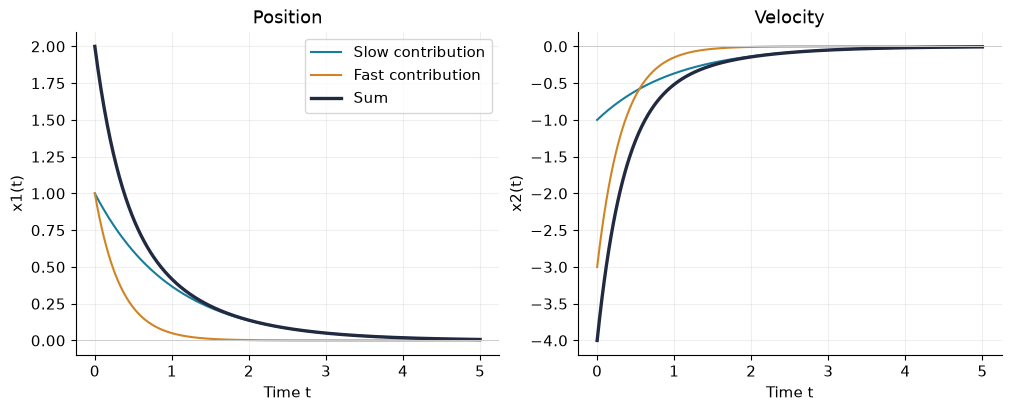

In [3]:
t_real = np.linspace(0., 5., 501)
terms_real, x_real = modal_response(P_real, lam_real, c_real, t_real)
x_reference = exact_response(A_real, x0_real, t_real)
error = np.max(np.abs(x_real - x_reference))
assert np.allclose(x_real, x_reference, atol=1e-12)
print(f"Maximum modal reconstruction error: {error:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for j, ax in enumerate(axes):
    ax.plot(t_real, terms_real[:, j, 0], color=SLOW, label="Slow contribution")
    ax.plot(t_real, terms_real[:, j, 1], color=FAST, label="Fast contribution")
    ax.plot(t_real, x_real[:, j], color=TOTAL, lw=2.4, label="Sum")
    ax.set(xlabel="Time t", ylabel=f"x{j + 1}(t)",
           title=["Position", "Velocity"][j])
    ax.axhline(0, color="0.8", lw=.7)
    ax.grid(alpha=.2)
axes[0].legend()
plt.show()

### 2.3 Geometric addition at the same time
The next plot shows the modal endpoints and the complete state trajectory. The arrows add the two modal vectors **head to tail at one common time**. Each modal contribution stays on its eigenvector line, while their sum generally follows a curve.

Change `t_mark` to see how the vector sum changes. The plotting conventions for a full phase portrait are introduced in Section 4.

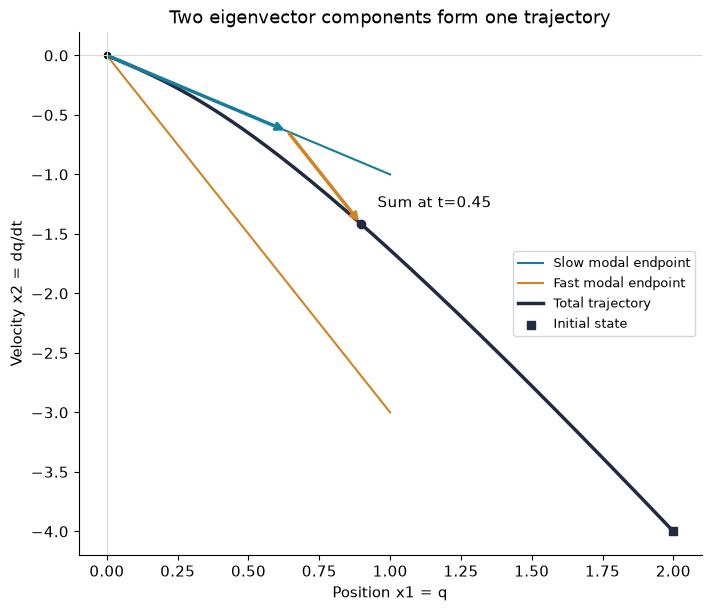

In [4]:
t_mark = 0.45
parts_mark = P_real * (c_real * np.exp(lam_real * t_mark))[None, :]
first, second = parts_mark[:, 0], parts_mark[:, 1]

fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
for i, color in enumerate([SLOW, FAST]):
    ax.plot(terms_real[:, 0, i], terms_real[:, 1, i], color=color,
            label=["Slow modal endpoint", "Fast modal endpoint"][i])
ax.plot(x_real[:, 0], x_real[:, 1], color=TOTAL, lw=2.5, label="Total trajectory")
ax.annotate("", xy=first, xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", lw=2.5, color=SLOW))
ax.annotate("", xy=first + second, xytext=first,
            arrowprops=dict(arrowstyle="->", lw=2.5, color=FAST))
ax.scatter(*(first + second), color=TOTAL, zorder=5)
ax.annotate(f"Sum at t={t_mark:g}", first + second, xytext=(12, 12),
            textcoords="offset points")
ax.scatter(*x0_real, color=TOTAL, marker="s", label="Initial state")
ax.scatter(0, 0, color="black", s=20)
ax.axhline(0, color="0.85", lw=.8)
ax.axvline(0, color="0.85", lw=.8)
ax.set(xlabel="Position x1 = q", ylabel="Velocity x2 = dq/dt",
       title="Two eigenvector components form one trajectory")
ax.legend(loc="best", fontsize=9)
plt.show()

### 2.4 Which modes does the initial condition excite?
Compare a pure slow mode, a pure fast mode, their sum, and zero initial velocity. Long-time alignment with the slow eigenvector requires its coefficient to be nonzero. Eigenvector normalization changes coefficients, so compare complete modal contributions rather than coefficient values alone.

Pure slow             : c = [ 1. -0.]
Pure fast             : c = [0. 1.]
Both modes            : c = [1. 1.]
Zero initial velocity : c = [ 1.5 -0.5]


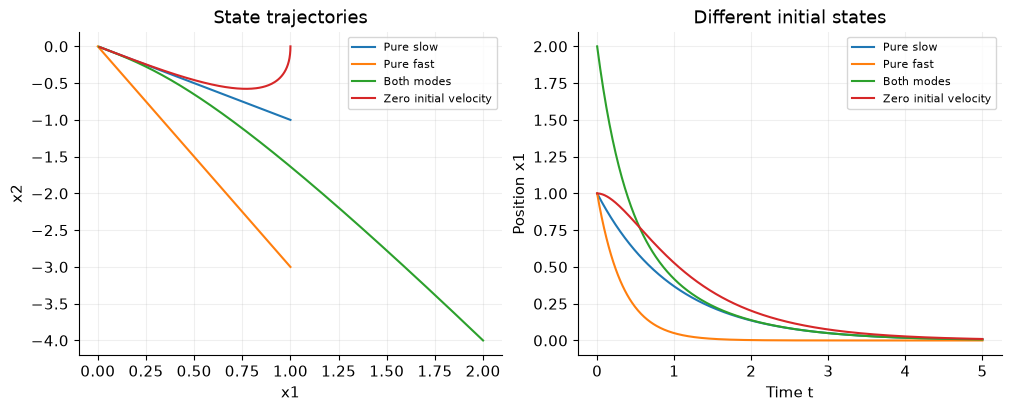

In [5]:
initial_states = {
    "Pure slow": P_real[:, 0],
    "Pure fast": P_real[:, 1],
    "Both modes": P_real[:, 0] + P_real[:, 1],
    "Zero initial velocity": np.array([1., 0.]),
}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for label, initial in initial_states.items():
    c = np.linalg.solve(P_real, initial)
    _, x = modal_response(P_real, lam_real, c, t_real)
    print(f"{label:22s}: c = {c}")
    axes[0].plot(x[:, 0], x[:, 1], label=label)
    axes[1].plot(t_real, x[:, 0], label=label)
axes[0].set(xlabel="x1", ylabel="x2", title="State trajectories")
axes[1].set(xlabel="Time t", ylabel="Position x1", title="Different initial states")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
plt.show()

## 3. Real and complex modes
### 3.2 A real initial state requires conjugate coefficients
Return to the damped oscillator from Week 3:
$$A=\begin{bmatrix}0&1\\-2&-0.6\end{bmatrix},\qquad
\lambda=\alpha+i\beta=-0.3+i\sqrt{1.91},\qquad v=\begin{bmatrix}1\\\lambda\end{bmatrix}.$$
Choose the eigenvectors as **exact conjugates**, $P=[v,\overline v]$. Start with
$$x_0=c_1v+c_2\overline v.$$
Because $x_0=\overline{x_0}$ and the two eigenvectors are independent, $c_2=\overline{c_1}$. Consequently,
$$x(t)=c_1e^{\lambda t}v+\overline{c_1e^{\lambda t}v}
=2\operatorname{Re}(c_1e^{\lambda t}v).$$
The imaginary-valued parts cancel at every time. The sine and cosine dependence remains.

In [6]:
A_complex = np.array([[0., 1.], [-2., -.6]])
alpha = -.3
beta = np.sqrt(1.91)
lam = alpha + 1j * beta
v = np.array([1., lam])
P_complex = np.column_stack([v, v.conj()])
lam_pair = np.array([lam, lam.conjugate()])
x0_complex = np.array([1., 0.])
c_complex = np.linalg.solve(P_complex, x0_complex)

assert np.allclose(A_complex @ P_complex, P_complex @ np.diag(lam_pair))
assert np.allclose(P_complex @ c_complex, x0_complex)
assert np.allclose(c_complex[1], c_complex[0].conjugate())
print("Eigenvalues:", lam_pair)
print("Coefficients:", c_complex)
print("c2 - conjugate(c1):", c_complex[1] - c_complex[0].conjugate())

t_complex = np.linspace(0., 15., 1001)
terms_complex, paired = modal_response(P_complex, lam_pair, c_complex, t_complex)
x_complex = paired.real
x_complex_reference = exact_response(A_complex, x0_complex, t_complex)
assert np.max(np.abs(paired.imag)) < 1e-12
assert np.allclose(x_complex, x_complex_reference, atol=1e-12)

# The real-coordinate formula in Section 3.2 gives the same response.
p, q = v.real, v.imag
a, b = np.linalg.solve(np.column_stack([p, q]), x0_complex)
assert np.allclose(c_complex[0], (a - 1j * b) / 2)
x_from_real_basis = np.array([
    np.exp(alpha * t) * (a * (p * np.cos(beta*t) - q * np.sin(beta*t))
                        + b * (p * np.sin(beta*t) + q * np.cos(beta*t)))
    for t in t_complex
])
assert np.allclose(x_from_real_basis, x_complex_reference)
print("Maximum imaginary remainder:", np.max(np.abs(paired.imag)))
print("Maximum response error:", np.max(np.abs(x_complex - x_complex_reference)))

Eigenvalues: [-0.3+1.38203j -0.3-1.38203j]
Coefficients: [0.5-0.10854j 0.5+0.10854j]
c2 - conjugate(c1): (5.551115123125783e-17+1.3877787807814457e-17j)
Maximum imaginary remainder: 1.1102230246251565e-16
Maximum response error: 2.681188604469753e-14


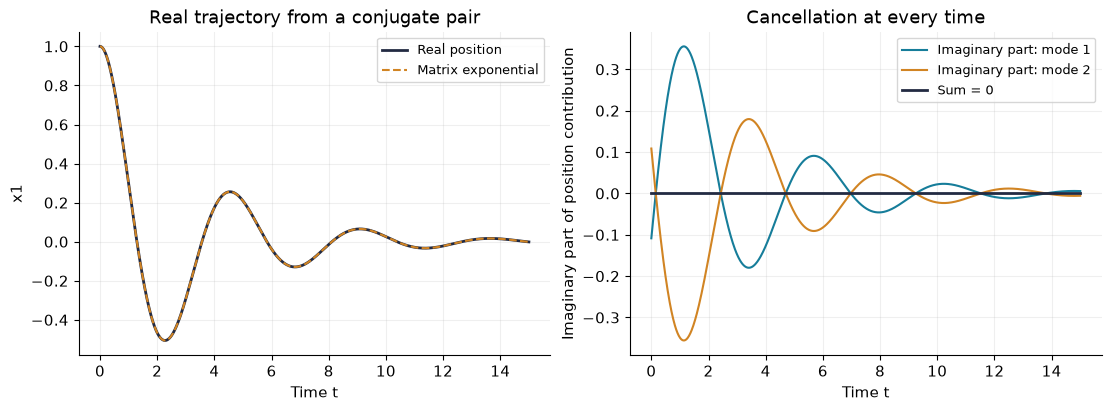

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(t_complex, x_complex[:, 0], color=TOTAL, lw=2, label="Real position")
axes[0].plot(t_complex, x_complex_reference[:, 0], "--", color=FAST,
             label="Matrix exponential")
axes[0].set(xlabel="Time t", ylabel="x1", title="Real trajectory from a conjugate pair")
axes[1].plot(t_complex, terms_complex[:, 0, 0].imag, color=SLOW,
             label="Imaginary part: mode 1")
axes[1].plot(t_complex, terms_complex[:, 0, 1].imag, color=FAST,
             label="Imaginary part: mode 2")
axes[1].plot(t_complex, paired[:, 0].imag, color=TOTAL, lw=2, label="Sum = 0")
axes[1].set(xlabel="Time t", ylabel="Imaginary part of position contribution",
            title="Cancellation at every time")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=9)
plt.show()

### 3.2 Oscillation comes from the imaginary part
$$e^{(\alpha+i\beta)t}=e^{\alpha t}(\cos\beta t+i\sin\beta t),\qquad
\omega=|\beta|,\quad T=\frac{2\pi}{|\beta|},\quad f=\frac{|\beta|}{2\pi}.$$
To isolate the effect of $\beta$, use
$$A_{\alpha,\beta}=\begin{bmatrix}\alpha&-\beta\\\beta&\alpha\end{bmatrix},\qquad x_0=[1,0]^T.$$
Then $x_1(t)=e^{\alpha t}\cos(\beta t)$. Keep $\alpha$ fixed and change $\beta$: the decay envelope stays the same while the oscillation period changes. The complete response is periodic only when $\alpha=0$; for nonzero $\alpha$, $T$ is the period of the sinusoidal factor.

beta=0.7: omega=0.700, T=8.976, f=0.111
beta=1.4: omega=1.400, T=4.488, f=0.223
beta=2.8: omega=2.800, T=2.244, f=0.446


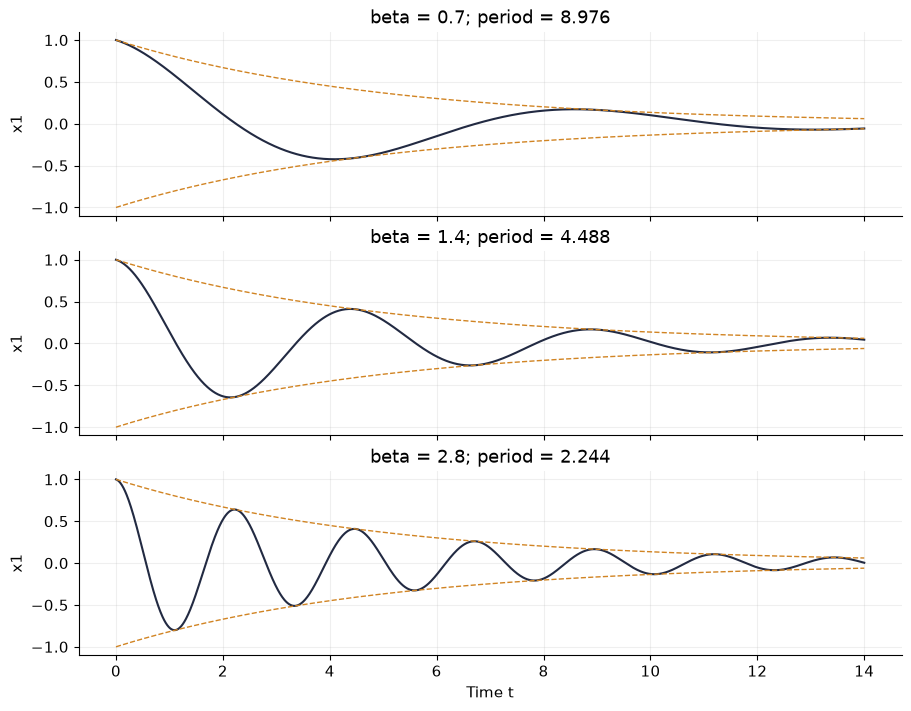

In [8]:
alpha_frequency = -.2
betas = [0.7, 1.4, 2.8]
t_frequency = np.linspace(0., 14., 1401)
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True, layout="constrained")
for ax, beta_frequency in zip(axes, betas):
    A_frequency = np.array([[alpha_frequency, -beta_frequency],
                            [beta_frequency, alpha_frequency]])
    x = exact_response(A_frequency, np.array([1., 0.]), t_frequency)
    envelope = np.exp(alpha_frequency * t_frequency)
    assert np.allclose(x[:, 0], envelope * np.cos(beta_frequency * t_frequency))
    period = 2 * np.pi / abs(beta_frequency)
    ax.plot(t_frequency, x[:, 0], color=TOTAL)
    ax.plot(t_frequency, envelope, "--", color=FAST, lw=1)
    ax.plot(t_frequency, -envelope, "--", color=FAST, lw=1)
    ax.set(ylabel="x1", title=f"beta = {beta_frequency:g}; period = {period:.3f}")
    ax.grid(alpha=.2)
    print(f"beta={beta_frequency:g}: omega={abs(beta_frequency):.3f}, "
          f"T={period:.3f}, f={abs(beta_frequency)/(2*np.pi):.3f}")
axes[-1].set_xlabel("Time t")
plt.show()

## 4. Phase portraits
### 4.1 Vector fields, trajectories, and time direction
A phase portrait plots $x_2$ against $x_1$. Time is a parameter, not an axis. Every solution curve is tangent to $Ax$, and arrows indicate increasing time.

The gallery uses the same six matrices as the course note. The spiral/center examples rotate counterclockwise; the physical oscillator in Section 3 rotates clockwise in $(q,\dot q)$ coordinates. Check $Ax$ at $(1,0)$ to distinguish them. The streamline arrows indicate direction, not a common speed.

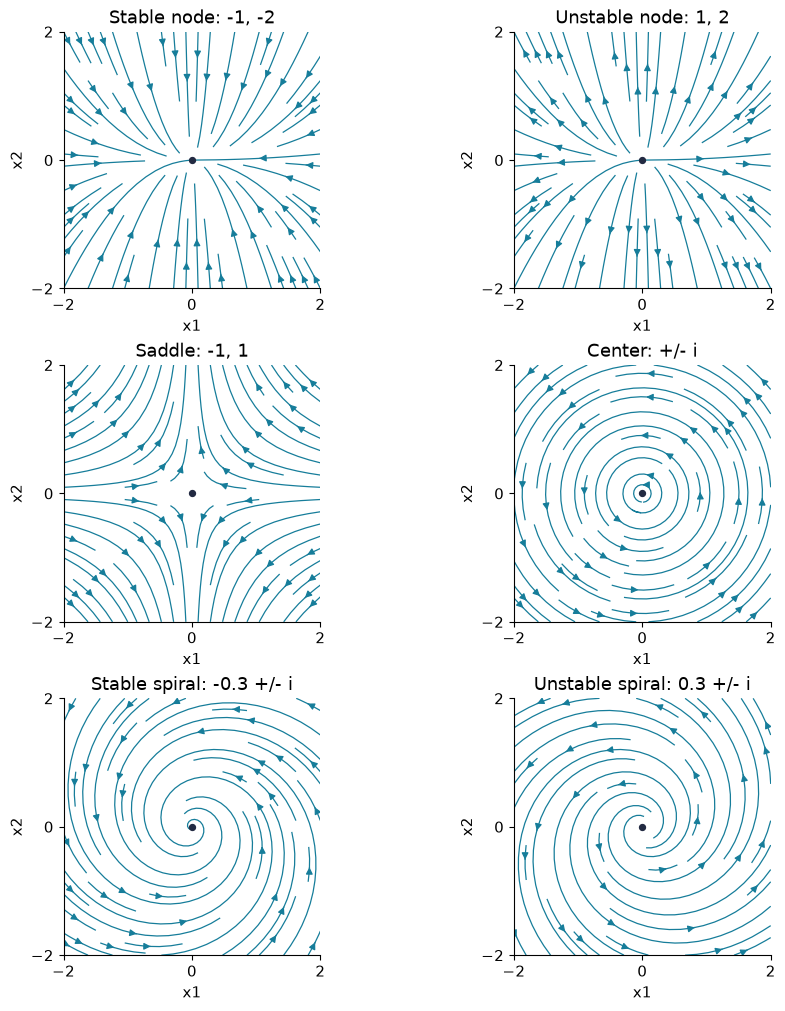

In [9]:
portrait_cases = [
    ("Stable node", np.diag([-1., -2.]), "-1, -2"),
    ("Unstable node", np.diag([1., 2.]), "1, 2"),
    ("Saddle", np.diag([-1., 1.]), "-1, 1"),
    ("Center", np.array([[0., -1.], [1., 0.]]), "+/- i"),
    ("Stable spiral", np.array([[-.3, -1.], [1., -.3]]), "-0.3 +/- i"),
    ("Unstable spiral", np.array([[.3, -1.], [1., .3]]), "0.3 +/- i"),
]
grid = np.linspace(-2., 2., 121)
X1, X2 = np.meshgrid(grid, grid)
fig, axes = plt.subplots(3, 2, figsize=(9, 10), layout="constrained")
for ax, (name, A, label) in zip(axes.flat, portrait_cases):
    U = A[0, 0] * X1 + A[0, 1] * X2
    V = A[1, 0] * X1 + A[1, 1] * X2
    ax.streamplot(grid, grid, U, V, density=.75, color=SLOW, linewidth=.9)
    ax.scatter(0, 0, color=TOTAL, s=18, zorder=5)
    ax.set(xlabel="x1", ylabel="x2", title=f"{name}: {label}",
           xlim=(-2, 2), ylim=(-2, 2), aspect="equal",
           xticks=[-2, 0, 2], yticks=[-2, 0, 2])
plt.show()

### 4.2 Eigenvalue classification, including the repeated cases
The table below matches the note's ordering: cases with distinct eigenvalues first, then all repeated-eigenvalue cases below a horizontal rule. These are **analytical classifications of the specified exact examples**. Floating-point eigenvalues alone are not a reliable test of Jordan structure.

In [10]:
classification_rows = [
    ("Distinct real, both negative", "Two eigenvectors", "Stable node", "Asymptotically stable"),
    ("Distinct real, both positive", "Two eigenvectors", "Unstable node", "Unstable"),
    ("Real, opposite signs", "Two eigenvectors", "Saddle", "Unstable"),
    ("alpha +/- i beta; alpha < 0", "Conjugate pair; beta != 0", "Stable spiral", "Asymptotically stable"),
    ("alpha +/- i beta; alpha > 0", "Conjugate pair; beta != 0", "Unstable spiral", "Unstable"),
    ("+/- i beta; beta != 0", "Conjugate pair", "Center", "Stable, not asymptotically stable"),
    ("0 and lambda < 0", "Two eigenvectors", "Attracting line of equilibria", "Stable, not asymptotically stable"),
    ("0 and lambda > 0", "Two eigenvectors", "Repelling line of equilibria", "Unstable"),
    ("Repeated real lambda != 0", "Two eigenvectors", "Star node", "AS if lambda < 0; unstable if lambda > 0"),
    ("Repeated real lambda != 0", "One eigenvector", "Improper node", "AS if lambda < 0; unstable if lambda > 0"),
    ("0, 0", "Two eigenvectors; A = 0", "Every state an equilibrium", "Stable, not asymptotically stable"),
    ("0, 0", "One eigenvector; A != 0", "Equilibrium line with shear", "Unstable"),
]
from html import escape
html = '<table style="border-collapse:collapse;text-align:left"><thead><tr>'
for heading in ["Eigenvalues", "Structure", "Equilibrium type", "Stability of origin"]:
    html += '<th style="padding:8px;border-bottom:2px solid #777">' + heading + '</th>'
html += '</tr></thead><tbody>'
for index, row in enumerate(classification_rows):
    border = 'border-top:2px solid #777;' if index == 8 else ''
    html += '<tr>' + ''.join(
        '<td style="padding:7px;vertical-align:top;' + border + '">' + escape(value) + '</td>'
        for value in row) + '</tr>'
html += '</tbody></table><p>AS = asymptotically stable. Stability refers to the origin, not attraction to a set.</p>'
display(HTML(html))

Eigenvalues,Structure,Equilibrium type,Stability of origin
"Distinct real, both negative",Two eigenvectors,Stable node,Asymptotically stable
"Distinct real, both positive",Two eigenvectors,Unstable node,Unstable
"Real, opposite signs",Two eigenvectors,Saddle,Unstable
alpha +/- i beta; alpha < 0,Conjugate pair; beta != 0,Stable spiral,Asymptotically stable
alpha +/- i beta; alpha > 0,Conjugate pair; beta != 0,Unstable spiral,Unstable
+/- i beta; beta != 0,Conjugate pair,Center,"Stable, not asymptotically stable"
0 and lambda < 0,Two eigenvectors,Attracting line of equilibria,"Stable, not asymptotically stable"
0 and lambda > 0,Two eigenvectors,Repelling line of equilibria,Unstable
Repeated real lambda != 0,Two eigenvectors,Star node,AS if lambda < 0; unstable if lambda > 0
Repeated real lambda != 0,One eigenvector,Improper node,AS if lambda < 0; unstable if lambda > 0


## 5. Stability of an equilibrium
- **Lyapunov stable:** for every $\varepsilon>0$, some $\delta>0$ guarantees that $\|x_0\|<\delta$ implies $\|x(t)\|<\varepsilon$ for all $t\ge0$.
- **Asymptotically stable:** stable and nearby trajectories converge to the equilibrium.
- **Exponentially stable:** $\|x(t)\|\le M e^{-\gamma t}\|x_0\|$, with $M\ge1$, $\gamma>0$.

Compare a decaying trajectory, a center, and two saddle trajectories. The saddle trajectory on the stable eigenspace converges; adding a small unstable component changes the long-term behavior. A finite simulation illustrates these definitions but cannot prove stability.

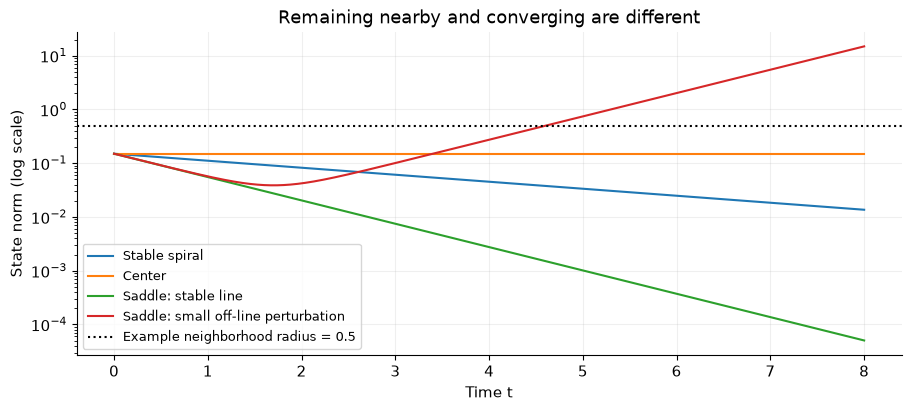

In [11]:
t_stability = np.linspace(0., 8., 801)
saddle = np.diag([-1., 1.])
stability_cases = [
    ("Stable spiral", np.array([[-.3, -1.], [1., -.3]]), np.array([.15, 0.])),
    ("Center", np.array([[0., -1.], [1., 0.]]), np.array([.15, 0.])),
    ("Saddle: stable line", saddle, np.array([.15, 0.])),
    ("Saddle: small off-line perturbation", saddle, np.array([.15, .005])),
]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
for name, A, initial in stability_cases:
    response = exact_response(A, initial, t_stability)
    ax.semilogy(t_stability, np.linalg.norm(response, axis=1), label=name)
ax.axhline(.5, color="black", ls=":", label="Example neighborhood radius = 0.5")
ax.set(xlabel="Time t", ylabel="State norm (log scale)", title="Remaining nearby and converging are different")
ax.grid(alpha=.2)
ax.legend(fontsize=9)
plt.show()

## 6. LTI stability and Jordan structure
For a finite-dimensional constant $A$:

- Every real part negative: asymptotically and exponentially stable.
- All real parts nonpositive, with semisimple imaginary-axis eigenvalues: Lyapunov stable.
- A positive real part, or a nontrivial imaginary-axis Jordan block: unstable.

Compare $A=0$, $J_0=\begin{bmatrix}0&1\\0&0\end{bmatrix}$, and $J_{-1}=\begin{bmatrix}-1&1\\0&-1\end{bmatrix}$. For $x_0=[0,1]^T$ their trajectories are $[0,1]^T$, $[t,1]^T$, and $e^{-t}[t,1]^T$, respectively. The first two matrices have the same eigenvalues and different stability.

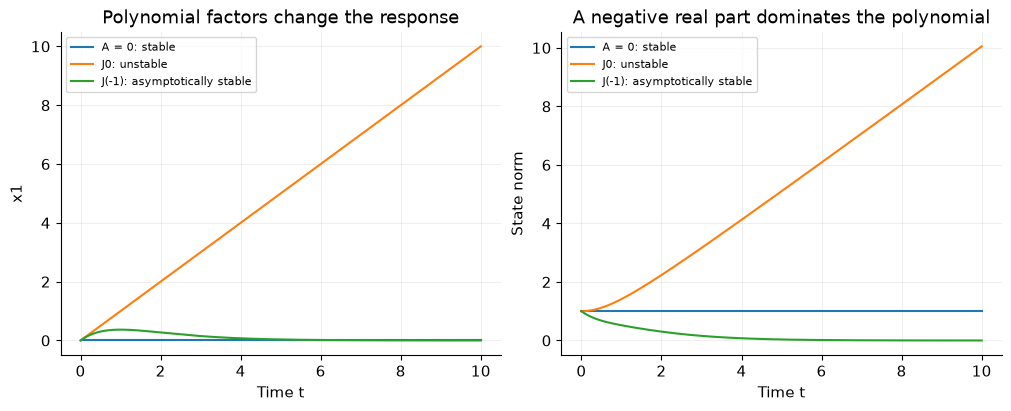

In [12]:
t_jordan = np.linspace(0., 10., 501)
x0_jordan = np.array([0., 1.])
J0 = np.array([[0., 1.], [0., 0.]])
Jminus = J0 - np.eye(2)
jordan_cases = [("A = 0: stable", np.zeros((2, 2))),
                ("J0: unstable", J0),
                ("J(-1): asymptotically stable", Jminus)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for name, A in jordan_cases:
    x = exact_response(A, x0_jordan, t_jordan)
    axes[0].plot(t_jordan, x[:, 0], label=name)
    axes[1].plot(t_jordan, np.linalg.norm(x, axis=1), label=name)
assert np.allclose(exact_response(J0, x0_jordan, t_jordan),
                   np.column_stack([t_jordan, np.ones_like(t_jordan)]))
assert np.allclose(exact_response(Jminus, x0_jordan, t_jordan),
                   np.exp(-t_jordan[:, None]) * np.column_stack([t_jordan, np.ones_like(t_jordan)]))
axes[0].set(xlabel="Time t", ylabel="x1", title="Polynomial factors change the response")
axes[1].set(xlabel="Time t", ylabel="State norm", title="A negative real part dominates the polynomial")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
plt.show()

**Core lecture stopping point.** The main sequence now matches Sections 2-6 of the note. The following two sections are optional extensions, followed by student investigations.

## 7. Optional extension: transient amplification
Reuse the non-normal example from Week 3:
$$A=\begin{bmatrix}-1&8\\0&-2\end{bmatrix},\qquad x_0=\begin{bmatrix}0\\1\end{bmatrix}.$$
With $v_1=[1,0]^T$, $v_2=[-8,1]^T$, start by expanding $x_0=8v_1+v_2$. Then
$$x(t)=8e^{-t}v_1+e^{-2t}v_2
=\begin{bmatrix}8(e^{-t}-e^{-2t})\\e^{-2t}\end{bmatrix}.$$
Initially the first components cancel. The cancellation weakens because the rates differ. At $t=\log2$, $\|x(t)\|=\sqrt{65}/4>1$. This time maximizes $x_1$, not necessarily the norm.

Initial coefficients: [8. 1.]
Norm at log(2): 2.0155644370746373


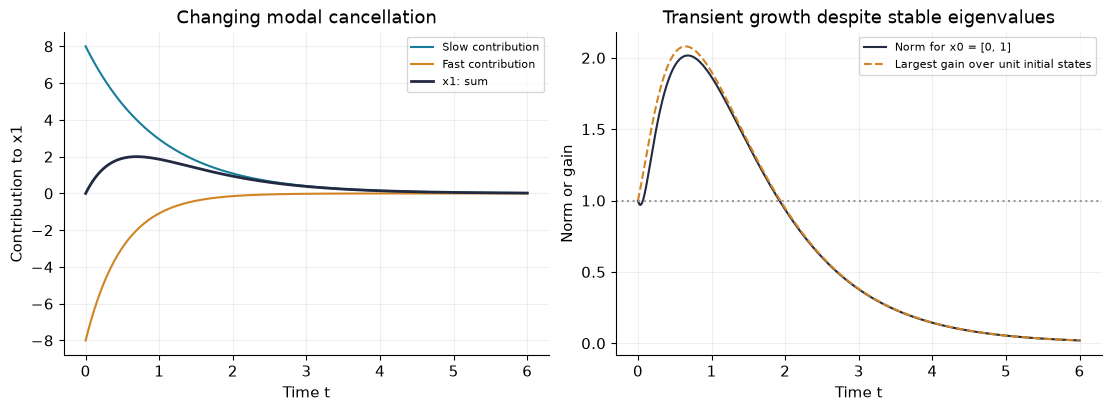

In [13]:
A_non = np.array([[-1., 8.], [0., -2.]])
P_non = np.array([[1., -8.], [0., 1.]])
x0_non = np.array([0., 1.])
c_non = np.linalg.solve(P_non, x0_non)
t_non = np.linspace(0., 6., 601)
terms_non, x_non = modal_response(P_non, np.array([-1., -2.]), c_non, t_non)
assert np.allclose(x_non, exact_response(A_non, x0_non, t_non))
state_at_log2 = expm(A_non * np.log(2)) @ x0_non
assert np.allclose(state_at_log2, [2., .25])
print("Initial coefficients:", c_non)
print("Norm at log(2):", np.linalg.norm(state_at_log2))

gain = np.array([svdvals(expm(A_non * t))[0] for t in t_non])
actual_norm = np.linalg.norm(x_non, axis=1)
assert np.all(actual_norm <= gain + 1e-12)  # initial norm is one
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(t_non, terms_non[:, 0, 0], color=SLOW, label="Slow contribution")
axes[0].plot(t_non, terms_non[:, 0, 1], color=FAST, label="Fast contribution")
axes[0].plot(t_non, x_non[:, 0], color=TOTAL, lw=2, label="x1: sum")
axes[0].set(xlabel="Time t", ylabel="Contribution to x1", title="Changing modal cancellation")
axes[1].plot(t_non, actual_norm, color=TOTAL, label="Norm for x0 = [0, 1]")
axes[1].plot(t_non, gain, "--", color=FAST, label="Largest gain over unit initial states")
axes[1].axhline(1, color="0.6", ls=":")
axes[1].set(xlabel="Time t", ylabel="Norm or gain", title="Transient growth despite stable eigenvalues")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=.2)
plt.show()

## 8. Optional extension: limits of linearization
The systems $\dot x=-x^3$ and $\dot x=x^3$ both have zero Jacobian at the origin, but the first is asymptotically stable and the second is unstable. Their exact solutions are
$$x_-(t)=\frac{x_0}{\sqrt{1+2x_0^2t}},\qquad
x_+(t)=\frac{x_0}{\sqrt{1-2x_0^2t}}.$$
The unstable solution exists only before $t_{\rm escape}=1/(2x_0^2)$ when $x_0\ne0$. Plot only times below that limit. Imaginary-axis eigenvalues in a nonlinear Jacobian require additional analysis.

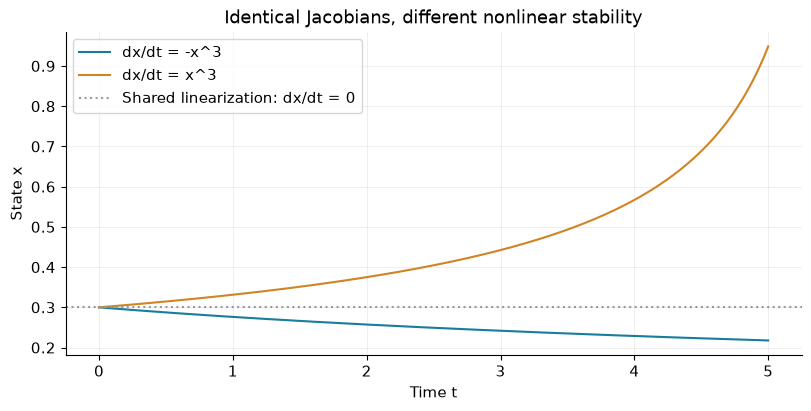

In [14]:
x0_nonlinear = .3  # use a nonzero initial state
t_escape = 1 / (2 * x0_nonlinear**2)
t_nonlinear = np.linspace(0., .9 * t_escape, 401)
x_minus = x0_nonlinear / np.sqrt(1 + 2 * x0_nonlinear**2 * t_nonlinear)
x_plus = x0_nonlinear / np.sqrt(1 - 2 * x0_nonlinear**2 * t_nonlinear)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(t_nonlinear, x_minus, color=SLOW, label="dx/dt = -x^3")
ax.plot(t_nonlinear, x_plus, color=FAST, label="dx/dt = x^3")
ax.axhline(x0_nonlinear, color="0.6", ls=":", label="Shared linearization: dx/dt = 0")
ax.set(xlabel="Time t", ylabel="State x", title="Identical Jacobians, different nonlinear stability")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 9-11. Review and student investigations

1. Set `x0_real = [1, 0]`. Predict the modal coefficients before running the code, and explain the negative coefficient.
2. Choose an initial state that removes the slow mode. Does the resulting trajectory eventually align with the slow direction?
3. For the complex oscillator, try three different real initial states. Verify the conjugate coefficient relation each time.
4. Deliberately choose two nonconjugate coefficients with $[v,\overline v]$. Compute their initial-state sum and explain why it is generally complex. Do not silently discard its imaginary part.
5. Double $|\beta|$ while holding $\alpha$ fixed. Predict which features of the response change.
6. Use the classification table to explain the six phase portraits. Verify their time directions by evaluating $Ax$ at a nonzero point.
7. Explain why a convergent trajectory on the saddle's stable line does not establish stability.
8. Compare the zero matrix and the defective zero-eigenvalue matrix. Identify the mechanism that makes only one unstable.
9. Optional: change the off-diagonal 8 in the transient-growth example and recompute its eigenvector basis. How do cancellation and amplification change?

**Numerical checks versus mathematical conclusions:** the assertions verify the implemented formulas. Stability for all initial states and all future times follows from the eigenvalue/Jordan criteria, not from a finite plotted trajectory.

## 12. Summary

- Expand $x_0$ in an eigenvector basis before evolving the state.
- Each pair $(\lambda_i,v_i)$ contributes $c_i e^{\lambda_i t}v_i$.
- With eigenvectors chosen as conjugate pairs, a real initial state requires conjugate coefficients.
- The imaginary part controls oscillation: $\omega=|\beta|$, $T=2\pi/|\beta|$.
- Eigenvalues identify the basic phase portrait; repeated eigenvalues also require eigenvector/Jordan structure.
- Negative real parts give asymptotic stability, while imaginary-axis Jordan blocks distinguish bounded motion from polynomial growth.
- Optional: nonorthogonal modes can temporarily amplify the state even when every mode decays.